In [3]:
import pandas as pd

df = pd.read_csv("dataset maskapai.csv")
df

,ID_Penerbangan,Maskapai,Asal,Tujuan,Durasi,Kapasitas_Kursi,Pax,Status_Penerbangan
0,FL-001,Garuda,Jakarta,Tokyo,7.5,300,285,Tepat Waktu
1,FL-002,Lion Air,Surabaya,Singapura,2.2,180,175,Delay
2,FL-003,AirAsia,Denpasar,Kuala Lumpur,3.0,180,160,Tepat Waktu
3,FL-004,Citilink,Medan,Jakarta,2.1,180,172,Tepat Waktu
4,FL-005,Garuda,Jakarta,Sydney,7.0,300,290,Tepat Waktu
...,...,...,...,...,...,...,...,...
405,FL-406,Citilink,Jakarta,Bali,"1,9",180,174,Tepat Waktu
406,FL-407,Batik Air,Surabaya,Makassar,"1,6",180,162,Delay
407,FL-408,Qatar Airways,Jakarta,Doha,"8,5",350,348,Tepat Waktu
408,FL-409,Emirates,Jakarta,Dubai,"8,6",350,325,Tepat Waktu


In [4]:
df["Asal"].value_counts()

Asal
Jakarta     161
Surabaya     96
Denpasar     67
Medan        64
Makassar     22
Name: count, dtype: int64

In [5]:
df.describe

<bound method NDFrame.describe of     ID_Penerbangan       Maskapai      Asal        Tujuan Durasi  \
0           FL-001         Garuda   Jakarta         Tokyo    7.5   
1           FL-002       Lion Air  Surabaya     Singapura    2.2   
2           FL-003        AirAsia  Denpasar  Kuala Lumpur    3.0   
3           FL-004       Citilink     Medan       Jakarta    2.1   
4           FL-005         Garuda   Jakarta        Sydney    7.0   
..             ...            ...       ...           ...    ...   
405         FL-406       Citilink   Jakarta          Bali    1,9   
406         FL-407      Batik Air  Surabaya      Makassar    1,6   
407         FL-408  Qatar Airways   Jakarta          Doha    8,5   
408         FL-409       Emirates   Jakarta         Dubai    8,6   
409         FL-410          Scoot  Surabaya     Singapore    2,2   

     Kapasitas_Kursi  Pax Status_Penerbangan  
0                300  285        Tepat Waktu  
1                180  175              Delay  
2       

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID_Penerbangan      410 non-null    object
 1   Maskapai            410 non-null    object
 2   Asal                410 non-null    object
 3   Tujuan              410 non-null    object
 4   Durasi              410 non-null    object
 5   Kapasitas_Kursi     410 non-null    int64 
 6   Pax                 410 non-null    int64 
 7   Status_Penerbangan  410 non-null    object
dtypes: int64(2), object(6)
memory usage: 25.8+ KB


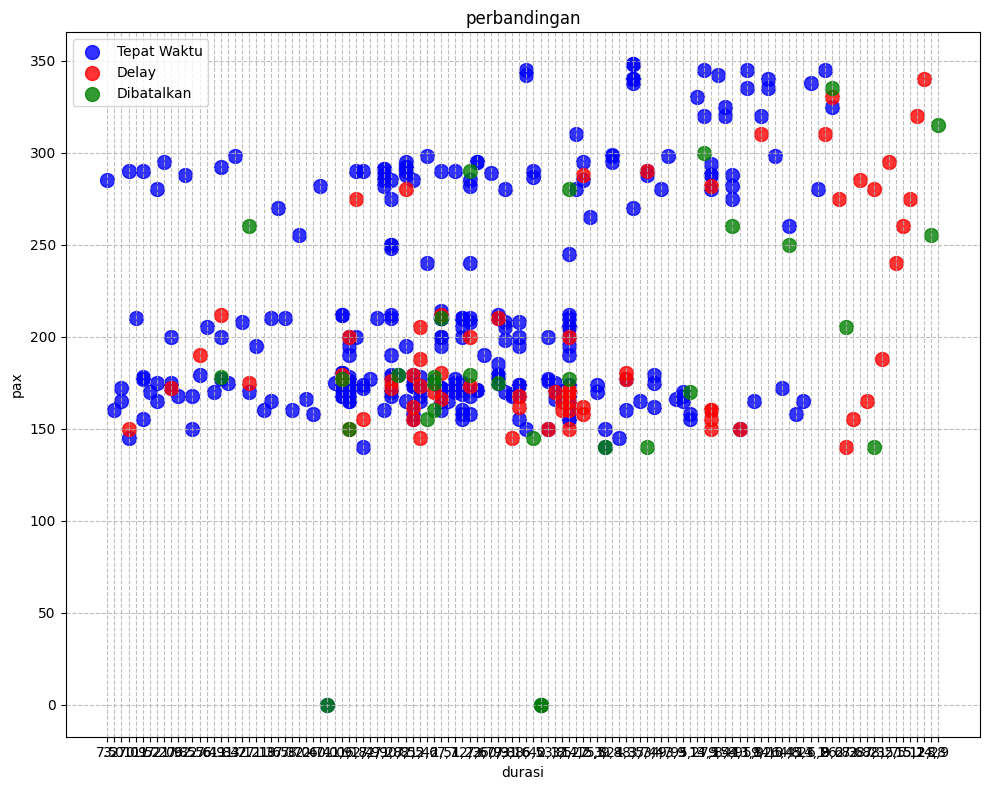

In [28]:
import matplotlib.pyplot as plt

tepat_waktu = df[df["Status_Penerbangan"]=="Tepat Waktu"]
delay = df[df["Status_Penerbangan"]=="Delay"]
dibatalkan = df[df["Status_Penerbangan"]=="Dibatalkan"]

plt.figure(figsize=(10,8))

plt.scatter(tepat_waktu["Durasi"], tepat_waktu["Pax"], s=100, alpha=0.8, color="blue", label="Tepat Waktu")
plt.scatter(delay["Durasi"], delay["Pax"], s=100, alpha=0.8, color="red", label="Delay")
plt.scatter(dibatalkan["Durasi"], dibatalkan["Pax"], s=100, alpha=0.8, color="green", label="Dibatalkan")
plt.xlabel("durasi")
plt.ylabel("pax")
plt.title("perbandingan")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.8)
plt.tight_layout()
plt.show()

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[["Maskapai","Asal","Tujuan","Durasi","Kapasitas_Kursi","Pax"]]
y = df["Status_Penerbangan"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["Durasi","Kapasitas_Kursi","Pax"]
categorical_columns = ["Maskapai","Asal","Tujuan"]

preprocessing = ColumnTransformer(
     transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_columns),

        ]
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", LogisticRegression())
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.7317073170731707

Classification Report :
               precision    recall  f1-score   support

       Delay       0.00      0.00      0.00        17
  Dibatalkan       0.00      0.00      0.00         4
 Tepat Waktu       0.74      0.98      0.85        61

    accuracy                           0.73        82
   macro avg       0.25      0.33      0.28        82
weighted avg       0.55      0.73      0.63        82


Confusion Matrix :
 [[ 0  0 17]
 [ 0  0  4]
 [ 0  1 60]]


In [31]:
print(df.dtypes)

ID_Penerbangan        object
Maskapai              object
Asal                  object
Tujuan                object
Durasi                object
Kapasitas_Kursi        int64
Pax                    int64
Status_Penerbangan    object
dtype: object


In [35]:
df["Durasi"] = df["Durasi"].str.replace(",", ".").astype(float)

In [36]:
print(df.dtypes)

ID_Penerbangan         object
Maskapai               object
Asal                   object
Tujuan                 object
Durasi                float64
Kapasitas_Kursi         int64
Pax                     int64
Status_Penerbangan     object
dtype: object


In [41]:
print(df["Status_Penerbangan"].value_counts())

Status_Penerbangan
Tepat Waktu    309
Delay           71
Dibatalkan      30
Name: count, dtype: int64


In [50]:
data_baru = pd.DataFrame([["Citilink","Medan","Jakarta", 2.1, 180, 172]],
                         columns=["Maskapai", "Asal","Tujuan","Durasi","Kapasitas_Kursi","Pax"])
prediksi = model.predict(data_baru)[0]
presentase = max(model.predict_proba(data_baru))[0]
print(f"model memprediksi {prediksi} dengan tingkat keyakinan {presentase*100:.2f}%")

model memprediksi Tepat Waktu dengan tingkat keyakinan 12.86%


In [51]:
import joblib

joblib.dump(model, "maskapai.joblib")

['maskapai.joblib']

In [52]:
print(df[["Durasi","Kapasitas_Kursi","Pax"]].describe())

           Durasi  Kapasitas_Kursi         Pax
count  410.000000       410.000000  410.000000
mean     3.966098       222.768293  206.673171
std      3.334321        58.203189   61.482027
min      0.000000       180.000000    0.000000
25%      1.600000       180.000000  168.250000
50%      2.200000       180.000000  178.000000
75%      7.000000       300.000000  260.000000
max     15.500000       350.000000  348.000000


In [53]:
print(df[["Maskapai","Asal","Tujuan"]].describe())

       Maskapai     Asal   Tujuan
count       410      410      410
unique       11        5       39
top      Garuda  Jakarta  Jakarta
freq         75      161       76


In [57]:
df["Tujuan"].value_counts()

Tujuan
Jakarta         76
Kuala Lumpur    37
Tokyo           36
Singapore       35
Sydney          29
Singapura       22
Denpasar        15
Bali            15
Doha            10
Dubai           10
Makassar         9
Bangkok          9
Seoul            8
Surabaya         8
Hong Kong        7
London           7
Batam            7
Perth            6
Yogyakarta       6
Jeddah           5
Taipei           5
Balikpapan       5
Melbourne        5
Padang           4
Manila           4
Ho Chi Minh      4
Palembang        4
Solo             3
Amsterdam        3
Paris            3
Semarang         3
Istanbul         2
Lombok           2
Pontianak        1
Medan            1
Johor Bahru      1
Milan            1
Osaka            1
Antalya          1
Name: count, dtype: int64